# Learning machine learning by doing small projects
# source - Pluto Academy -Internship prep
# PROJECT 01 Exploratory Data Analysis & Insights Report
# The Problem Statement
# You are a Data Analyst hired at a company. Your manager has given you a real-world dataset and asked you
# to understand the data, find patterns and trends, visualize the key insights, and write a clear report with 5
# business or research recommendations based on your findings.

In [5]:
# Here i am choosing the netflix movies & tv shows dataset

# Step 1: Data Collecting and Data inspecting

In [6]:
# step 1 load and inspect the data
import pandas as pd
import numpy as np
# load the data from custom file
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
from Codespace import file_paths

# take the dataframe
df = pd.read_csv(file_paths.NETFLIX_TITLE_PATH)

# check the data in dataframe
df.shape

(8807, 12)

In [7]:
# checking the null params columns
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [8]:
# checking for null/columns checking
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [9]:
# checking the duplicated rows are there
if df.duplicated().sum():
    # removing the duplicated rows
    print(f'We got the duplicated rows')
    df.drop_duplicates()
else:
    print(f'Dont have the duplicate records')

Dont have the duplicate records


# step2: Data cleaning

In [10]:
# # trying to check which dataframes has empty datasets
# if less number of empty rows -can remove them (if more important can able to fill with a value)
# if more means (can assign any parameter - related value)
# date should be of type date (in pandas there is to_datetime to convert to datetime)
# missing data columns director(2634), case (825), country (831), date_added(10), rating(4), duration(3) or you can check with above df.isnull().sum()

In [11]:
# removing the unwanted columns 
# which should not useful for the evaluation
df.drop(columns=["show_id", "description"], inplace=True)
# inplace = True means that it will change the original data frame

In [12]:
df.isnull().sum()

type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
dtype: int64

In [13]:
# we are going to fill the columns with Unknown as for director, cast, country
df.fillna({"director": "Unknown", "cast": "Uknown", "country": "Unknown"}, inplace=True)

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,Uknown,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries
1,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries"
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
3,TV Show,Jailbirds New Orleans,Unknown,Uknown,Unknown,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV"
4,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ..."
...,...,...,...,...,...,...,...,...,...,...
8802,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers"
8803,TV Show,Zombie Dumb,Unknown,Uknown,Unknown,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies"
8804,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies"
8805,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies"


In [14]:
# now we are going to remove the less number of records from rating, duration and date_added columns
df.dropna(subset=["rating", "duration", "date_added"], inplace=True)

In [15]:
# now again checking the null values
df.isnull().sum()
# we didn't get any empty records

type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [16]:
# now we will try to format the fields
# datetime field should be datetime not string
# removing the whitespaces
df["date_added"] = df["date_added"].str.strip()

# converting to datetime
df["date_added"] = pd.to_datetime(df["date_added"])

# splitting it to year and month - for charts
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

df["year_added"].value_counts().head()
df["month_added"].value_counts().head()

month_added
7     827
12    812
9     769
4     763
10    760
Name: count, dtype: int64

In [17]:
# let's change the duration of the movies
df["duration"] = df["duration"].str.strip()

# now lets divide the number and unit
df["duration_time"] = df["duration"].str.extract(r'(\d+)').astype(float)
df["duration_unit"] = df["duration"].str.extract(r'([A-Za-z]+)')


df[["duration", "duration_time", "duration_unit"]]

,duration,duration_time,duration_unit
0,90 min,90.0,min
1,2 Seasons,2.0,Seasons
2,1 Season,1.0,Season
3,1 Season,1.0,Season
4,2 Seasons,2.0,Seasons
...,...,...,...
8802,158 min,158.0,min
8803,2 Seasons,2.0,Seasons
8804,88 min,88.0,min
8805,88 min,88.0,min


In [18]:
# as listed_in is genre in real world taking the first one as currently it is a combination of genre
df["primary_genre"] = df["listed_in"].str.split(',').str[0].str.strip()

In [19]:
# checking the count of genres
df["primary_genre"].value_counts().head(10)

primary_genre
Dramas                      1599
Comedies                    1210
Action & Adventure           859
Documentaries                829
International TV Shows       773
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     385
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64

In [20]:
# now we need to strip the text columns here!!, type, rating , country
df["type"] = df["type"].str.strip()
df["country"] =  df["country"].str.strip()
df["rating"] = df["rating"].str.strip()
# we will make sure that type should be unique as well as rating
df["type"].unique()
df["rating"].unique()

<StringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',       'NR',
 'TV-Y7-FV',       'UR']
Length: 14, dtype: str

In [21]:
df.shape

(8790, 15)

In [22]:
df.dtypes

type                        str
title                       str
director                    str
cast                        str
country                     str
date_added       datetime64[us]
release_year              int64
rating                      str
duration                    str
listed_in                   str
year_added                int32
month_added               int32
duration_time           float64
duration_unit               str
primary_genre            object
dtype: object

In [23]:
df.head(5)

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,year_added,month_added,duration_time,duration_unit,primary_genre
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,Uknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,90.0,min,Documentaries
1,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries",2021,9,2.0,Seasons,International TV Shows
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,1.0,Season,Crime TV Shows
3,TV Show,Jailbirds New Orleans,Unknown,Uknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV",2021,9,1.0,Season,Docuseries
4,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",2021,9,2.0,Seasons,International TV Shows


# Step 3: EDA (Exploratory Data Analysis)

The goal of this step is to answer 5 questions

Question 1 — What is the split between Movies and TV Shows?

In [24]:
# just see the content type in Netflix
type_counts = df["type"].value_counts()
type_counts
# we can see the number of movies and TV shows in the netflix

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

In [25]:
# now we will get the percentage
df["type"].value_counts(normalize=True) * 100
# normalize will give the These values are calculated by dividing the count of each unique value by the sum of all counts,
# resulting in proportions that sum to 1.0 (excluding NaN values by default). 

type
Movie      69.692833
TV Show    30.307167
Name: proportion, dtype: float64

Question 2: Which countries would produce the most content?

In [26]:
content = df[df["country"]!="Unknown"]["country"].value_counts().head(5)
content

country
United States     2809
India              972
United Kingdom     418
Japan              243
South Korea        199
Name: count, dtype: int64

In [27]:
# so from the above values we can say that the country with most content is USA and India as first and second respectively.

Question 3: How has Netflix grown over the years?

In [28]:
yearly_growth = df.groupby("year_added")["title"].count()
yearly_growth

year_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: title, dtype: int64

In [29]:
# so we can see all the released movies/TV shows according to the year wise.
# now we can find the maximum (peak year films produce)
print("Peak Year: ", yearly_growth.idxmax())
print("Peak Count: ", yearly_growth.max())
print(f"Peak content of {yearly_growth.max()} are released in the Year {yearly_growth.idxmax()} ")

Peak Year:  2019
Peak Count:  2016
Peak content of 2016 are released in the Year 2019 


Question 4: What are the most common ratings?

In [30]:
# to find the common ratings
common_ratings = df["rating"].value_counts()
common_ratings.head(1)

rating
TV-MA    3205
Name: count, dtype: int64

In [31]:
# now we got the responose as TV-MA as the highest number rating moves in Netflix 3205

In [32]:
# If we want to find the percentage for the whole
adult_count = df[df["rating"].isin(["TV-MA", "R"])].value_counts().shape[0]
# without shape[0] it will return (rows, columns) shape[0] will return rows
total_count = df.shape[0]
print(f"Total: {total_count},\nAdult: {adult_count} &\nAdult Percentage: {round((adult_count/total_count)*100,2)}%")


Total: 8790,
Adult: 4004 &
Adult Percentage: 45.55%


Question 5:What is the most common genre?

In [33]:
# finding the most common genre
common_genre = df["primary_genre"].value_counts()
common_genre.head(5)

primary_genre
Dramas                    1599
Comedies                  1210
Action & Adventure         859
Documentaries              829
International TV Shows     773
Name: count, dtype: int64

# STEP 4: VISUALIZATION

In [34]:
# imports
import matplotlib.pyplot as plt
import seaborn as sns

# make sure the charts all
sns.set_theme(style="whitegrid")

Chart1 :Finding Countries with most content?

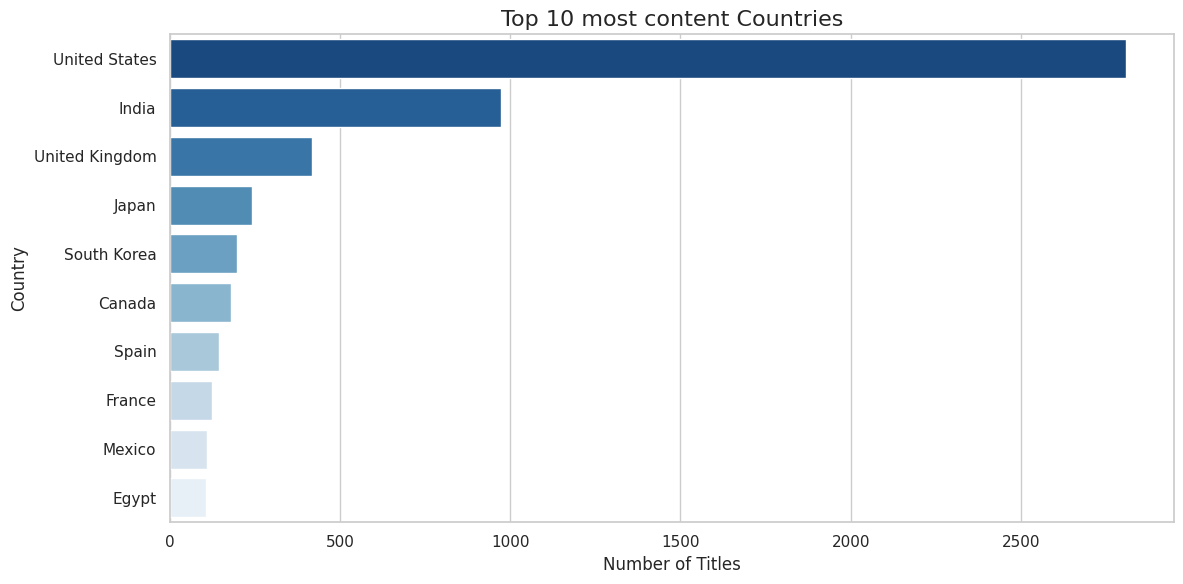

In [35]:
# finding the values(top_countries)
top_countries = df[df["country"]!="Unknown"]["country"].value_counts().head(10)
# as we are taking the first 10 we have to set x and y axis limit for pyplot
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette="Blues_r", legend=False)

plt.title("Top 10 most content Countries", fontsize=16)
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.show()